In [11]:
# Import pandas for data manipulation and loading datasets 
import pandas as pd

# Import numpy for numerical operations and array handling
import numpy as np

# Import train_test_split for dividing data and GridSearchCV for hyperparameter tuning 
from sklearn.model_selection import train_test_split, GridSearchCV

# Import OneHotEncoder for categorical variables and StandardScaler for feature scaling
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Import required models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Import evaluation tools for confusion matrices, reports, and ROC curve plotting
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, RocCurveDisplay

# Import matplotlib and seaborn for creating the required performance visualizations
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
#reading the csv
df = pd.read_csv("classification_dataset.csv")

#Get the top rows to see a sample from dataset
df.head()

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0
1,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0
2,40.0,131004,MORTGAGE,9,VENTURE,30000,7.90,0.23,N,13,0
3,40.0,150000,MORTGAGE,9,DEBTCONSOLIDATION,25000,11.89,0.17,N,11,0
4,40.0,132000,MORTGAGE,3,HOMEIMPROVEMENT,25000,16.82,0.22,N,17,0


In [13]:
#Split features and target
x = df.drop(columns=['loan_approval_status'])
y = df['loan_approval_status']

In [14]:
# Display the list of feature names used for modelling.
print("Feature names used for classification:")
print(list(x.columns))

print()

# Display the shape of the input feature matrix.
print("x shape:", x.shape)

# Display the shape of the target variable.
print("y shape:", y.shape)

Feature names used for classification:
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']

x shape: (58623, 10)
y shape: (58623,)


In [15]:
#Split the features and targets into train and test

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [16]:
#Seperating the columns as numerical and categorical for scalng and encoding

num_cols = x_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = x_train.select_dtypes(include=['object']).columns

In [17]:
#Making a pipeline with both scaler and encoder and saving them as transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

In [18]:
# Fit the scaler on the training classification features and transform them
x_train = preprocessor.fit_transform(x_train)

# Transform the test classification features using the training-fitted scaler
x_test = preprocessor.transform(x_test)

In [19]:
#Modelling Logistic Regression with max_iter = 1000 to shape the gradient descent
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)

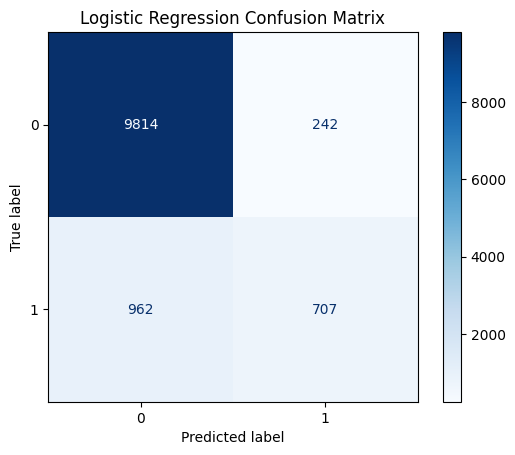

              precision    recall  f1-score   support

           0       0.91      0.98      0.94     10056
           1       0.74      0.42      0.54      1669

    accuracy                           0.90     11725
   macro avg       0.83      0.70      0.74     11725
weighted avg       0.89      0.90      0.88     11725



In [20]:
#Display confusion matrix for Logistic Regression

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()
print(classification_report(y_test, y_pred_lr))

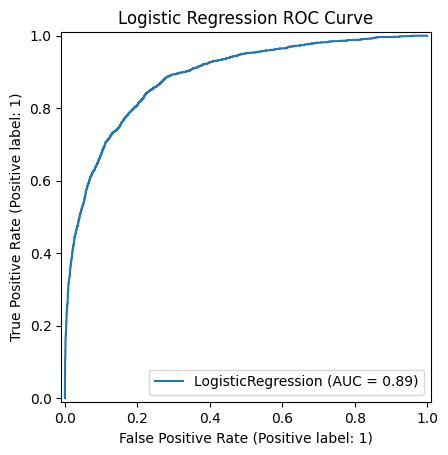

In [21]:
# Plot the ROC curve for Logistic Regression.
RocCurveDisplay.from_estimator(lr, x_test, y_test)

# Add a title to the ROC plot.
plt.title('Logistic Regression ROC Curve')

# Display the ROC plot.
plt.show()

In [23]:
#Modeling Gaussian Naive Baiyes 

nb = GaussianNB()
nb.fit(x_train, y_train)

y_pred_nb = nb.predict(x_test)

Gaussian Naive Baiyes


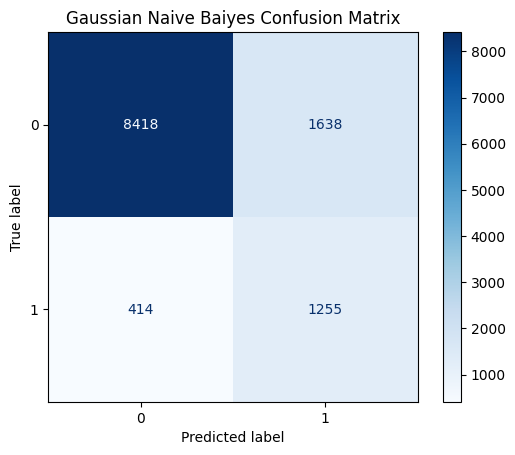

              precision    recall  f1-score   support

           0       0.95      0.84      0.89     10056
           1       0.43      0.75      0.55      1669

    accuracy                           0.82     11725
   macro avg       0.69      0.79      0.72     11725
weighted avg       0.88      0.82      0.84     11725



In [24]:
#Display confusion matrix for Naive Baiyes

print("Gaussian Naive Baiyes")
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb, cmap='Blues')
plt.title("Gaussian Naive Baiyes Confusion Matrix")
plt.show()
print(classification_report(y_test, y_pred_nb))

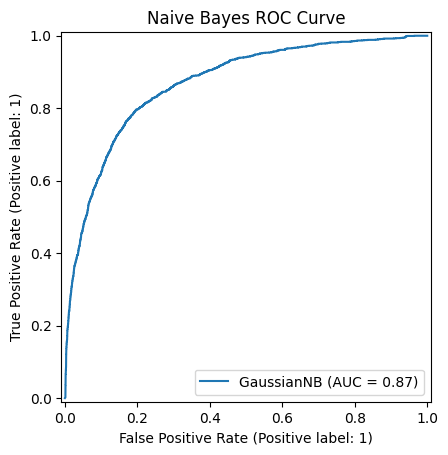

In [25]:
# Plot the ROC curve for Naive Bayes.
RocCurveDisplay.from_estimator(nb, x_test, y_test)

# Add a title to the ROC plot.
plt.title('Naive Bayes ROC Curve')

# Display the ROC plot.
plt.show()

In [26]:
#Modeling KNN

knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(x_train, y_train)

y_pred_knn = knn.predict(x_test)

KNeighborsClassifier


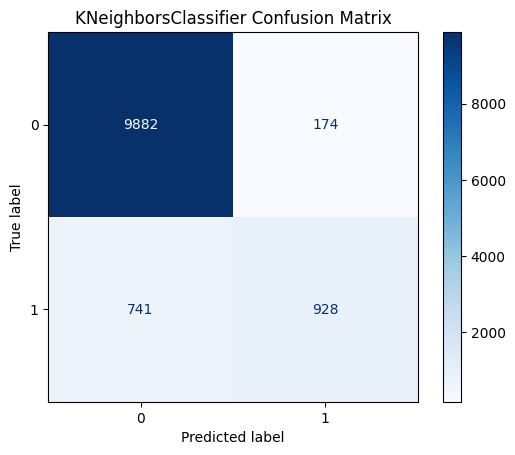

              precision    recall  f1-score   support

           0       0.93      0.98      0.96     10056
           1       0.84      0.56      0.67      1669

    accuracy                           0.92     11725
   macro avg       0.89      0.77      0.81     11725
weighted avg       0.92      0.92      0.92     11725



In [27]:
#Display confusion matrix for KNN

print("KNeighborsClassifier")
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, cmap='Blues')
plt.title("KNeighborsClassifier Confusion Matrix")
plt.show()
print(classification_report(y_test, y_pred_knn))

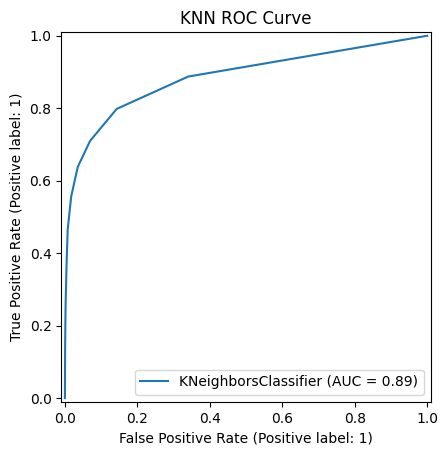

In [28]:
# Plot the ROC curve for KNN
RocCurveDisplay.from_estimator(knn, x_test, y_test)

# Add a title to the ROC plot.
plt.title('KNN ROC Curve')

# Display the ROC plot.
plt.show()

In [30]:
#Print all the precision and recall score for the models
from sklearn.metrics import precision_score, recall_score

models = {
    "LR": y_pred_lr,
    "NB": y_pred_nb,
    "KNN": y_pred_knn
}

for name, pred in models.items():
    print(f"{name} Precision:", precision_score(y_test, pred, pos_label=0))
    print(f"{name} Recall:", recall_score(y_test, pred, pos_label=0))
    print()

LR Precision: 0.9107275426874536
LR Recall: 0.9759347653142403

NB Precision: 0.953125
NB Recall: 0.8371121718377088

KNN Precision: 0.9302456933069755
KNN Recall: 0.9826968973747017



In [33]:
# Import make_scorer to create a custom metric and f1_score to measure model balance
from sklearn.metrics import make_scorer, f1_score

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15]
}

# Initialize GridSearchCV to find the best k-value using 5-fold cross-validation
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    # Set scoring to F1-score for the 'Approved' class (0) to satisfy success criteria
    scoring=make_scorer(f1_score, pos_label=0) 
)

# Fit the grid search model to the training data to find the optimal parameters
grid_knn.fit(x_train, y_train)

print("Best K:", grid_knn.best_params_)

Best K: {'n_neighbors': 11}


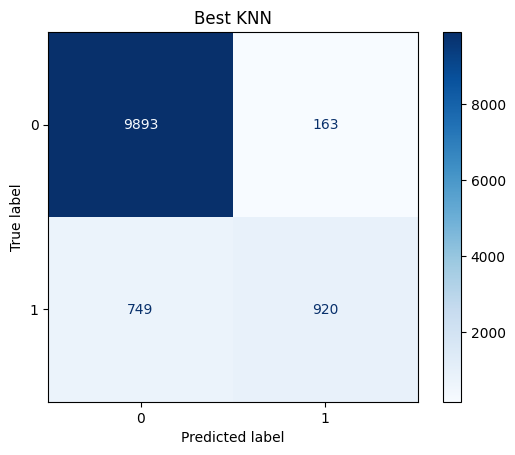

              precision    recall  f1-score   support

           0       0.93      0.98      0.96     10056
           1       0.85      0.55      0.67      1669

    accuracy                           0.92     11725
   macro avg       0.89      0.77      0.81     11725
weighted avg       0.92      0.92      0.92     11725



In [34]:
#Get the best tuned model
best_knn = grid_knn.best_estimator_

#Predict with test data
y_pred_best = best_knn.predict(x_test)

#Print matrix display
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, cmap='Blues')
plt.title("Best KNN")
plt.show()
print(classification_report(y_test, y_pred_best))

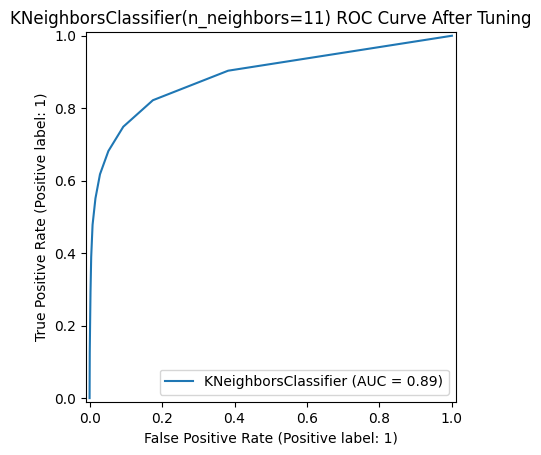

In [36]:
# Plot the ROC curve for the tuned best model.
RocCurveDisplay.from_estimator(best_knn, x_test, y_test)

# Add a title to the ROC plot.
plt.title(f'{best_knn} ROC Curve After Tuning')

# Display the ROC plot.
plt.show()